In [1]:
import os
from pathlib import Path

os.environ["NJ_DOMAIN"] = "v1_5_raritan"  # must precede the nj_sfincs import

import sys

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "nj_sfincs").is_dir())
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import HTML, display

from nj_sfincs import animate, domain, plots

DOM = domain.active()
EXP = ROOT / "experiments" / DOM.name

# All three arms. Keys are the panel labels.
RUNS = {
    "naccs-premier": "naccs-premier",
    "noaa-2node": "noaa-2node",
    "naccs-nowaves": "naccs-nowaves",
}

print(DOM.name, "|", sorted(DOM.map_windows))
print({k: (EXP / v / "sfincs_map.nc").exists() for k, v in RUNS.items()})


v1_5_raritan | ['arthur_kill', 'domain', 'narrows', 'raritan', 'sandy_hook']
{'naccs-premier': True, 'noaa-2node': True, 'naccs-nowaves': True}


## NACCS forcing vs gauges — forcing-product diagnostic, no SFINCS run


[read] cache hit — 1287 save points from _sandy_parsed.npz


,gauge,node,dist_km,n,naccs_bias,naccs_rmse,naccs_peak_err,pct_battery,n2_bias,n2_rmse,n2_peak_err,crest
0,sss_great_kills,11726,0.69,112,-0.389,0.410,-0.350,88,-0.556,0.583,-0.789,ok
1,sss_arthur_kill_mouth,11719,0.46,614,-0.007,0.168,0.168,83,-0.151,0.251,-0.684,ok
2,sss_narrows_si,4003,0.28,204,-0.092,0.178,0.001,92,-0.105,0.177,-0.147,ok
3,sss_narrows_bkln,14069,0.43,524,-0.060,0.171,0.053,92,-0.057,0.218,-0.045,ok
4,sandy_hook,3798,0.69,48,-0.162,0.181,-0.164,84,-0.119,0.160,-0.316,FLOOR
5,usgs_stormtide_sea_bright,11519,0.27,28,-0.601,0.611,-0.509,77,-0.647,0.692,-0.439,ok
6,usgs_tidal_sea_bright,13733,0.67,520,-0.032,0.129,NaN,77,-0.072,0.250,NaN,FLOOR
7,usgs_tidal_shark_river,11489,0.22,520,0.019,0.126,NaN,63,-0.104,0.125,NaN,FLOOR


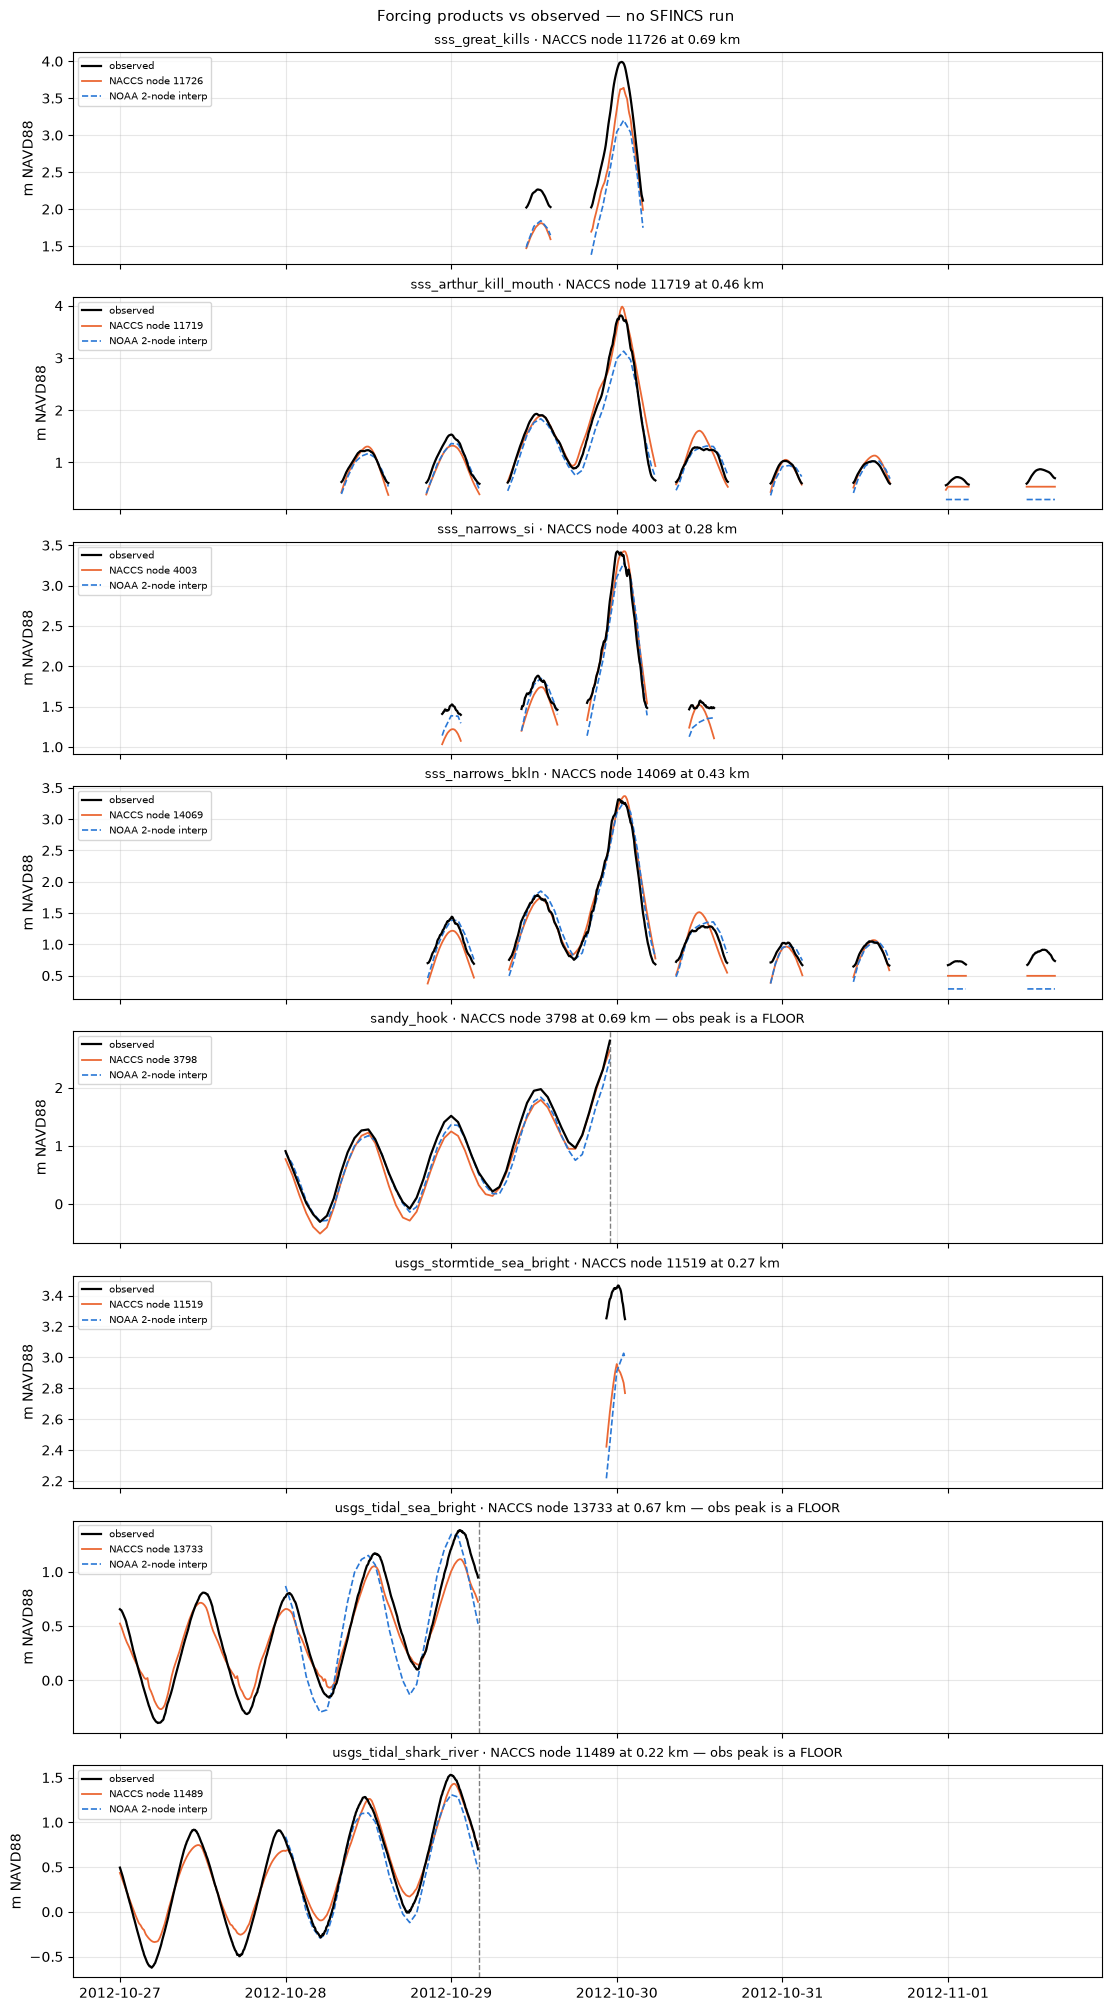

In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

sys.path.insert(0, str(ROOT / "scripts"))
from build_naccs_boundary import DRY, read_zips
from check_naccs_vs_sensors import MIN_NODE_DEPTH_M, _m, naccs_series

from nj_sfincs.validate.metrics import _obs_series

CREST = (pd.Timestamp("2012-10-29 12:00"), pd.Timestamp("2012-10-30 12:00"))
NOAA_PAIR = (8518750, 8534720)  # the incumbent: Battery + Atlantic City, both OUTSIDE


def break_gaps(s, tol=3.0):
    """NaN across sampling gaps so the line breaks instead of spanning a clipped stretch."""
    if len(s) < 3:
        return s
    d = s.index.to_series().diff()
    step = d.median()
    brk = s.index[d > tol * step]
    return s if not len(brk) else pd.concat(
        [s, pd.Series(np.nan, index=brk - step)]
    ).sort_index()


def _xy(lon, lat, lat0):
    return lon * 111320.0 * math.cos(math.radians(lat0)), lat * 111320.0


nd = xr.open_dataset(ROOT / "data" / "gtsm" / "noaa_sandy_nj.nc")
_st = list(nd["stations"].values)
_ia, _ib = _st.index(NOAA_PAIR[0]), _st.index(NOAA_PAIR[1])
_t = pd.to_datetime(nd["time"].values)
_sa = pd.Series(nd["waterlevel"].values[:, _ia], index=_t)
_sb = pd.Series(nd["waterlevel"].values[:, _ib], index=_t)
_pa = (float(nd["lon"].values[_ia]), float(nd["lat"].values[_ia]))
_pb = (float(nd["lon"].values[_ib]), float(nd["lat"].values[_ib]))


def two_node(lon, lat):
    """The incumbent 2-node forcing at a point: linear between the two NOAA gauges.

    Returns (series, weight_on_the_far_gauge). Both anchors sit outside Raritan Bay, so a
    linear blend of them cannot produce an interior maximum — that is the structural claim
    v1.5 rests on, not a measured margin.
    """
    ax, ay = _xy(*_pa, _pa[1])
    bx, by = _xy(*_pb, _pa[1])
    gx, gy = _xy(lon, lat, _pa[1])
    vx, vy = bx - ax, by - ay
    w = ((gx - ax) * vx + (gy - ay) * vy) / (vx * vx + vy * vy)
    w = min(max(w, 0.0), 1.0)
    return (1 - w) * _sa + w * _sb, w


pts = read_zips(use_cache=True)
times = pts.pop("_times")
# -99999 is DRY, not missing. Screen deep AND never-dry, as build_naccs_boundary does.
wet = [p for p in pts
       if np.min(np.asarray(pts[p]["wl"], float)) > DRY
       and pts[p]["depth"] >= MIN_NODE_DEPTH_M]


def _align(obs, s):
    return pd.concat(
        [obs.rename("obs"),
         s.reindex(obs.index.union(s.index)).interpolate("time").rename("mod")],
        axis=1, sort=True,
    ).loc[obs.index].dropna()


rows, panels = [], []
for g in DOM.obs_gauges:
    o = _obs_series(g)
    if o is None:
        continue
    obs = pd.Series(o[1], index=pd.to_datetime(o[0])).dropna()
    if obs.empty:
        continue
    censored = bool(g.record_ends) and not g.survives_crest  # obs peak is a FLOOR
    if g.record_ends:
        obs = obs.loc[: pd.Timestamp(g.record_ends)]

    sp = min(wet, key=lambda p: _m(g.lat, g.lon, pts[p]["lat"], pts[p]["lon"]))
    dist = _m(g.lat, g.lon, pts[sp]["lat"], pts[sp]["lon"])
    both = _align(obs, naccs_series(pts, times, sp))          # NACCS
    n2, w2 = two_node(g.lon, g.lat)
    b2 = _align(obs, n2)                                       # incumbent 2-node
    if both.empty:
        continue

    crest = both.loc[CREST[0]:CREST[1]]
    pk_o, pk_m = crest["obs"].max(), crest["mod"].max()
    c2 = b2.loc[CREST[0]:CREST[1]]
    rows.append(dict(
        gauge=g.name, node=sp, dist_km=round(dist / 1000, 2), n=len(both),
        naccs_bias=round((both["mod"] - both["obs"]).mean(), 3),
        naccs_rmse=round(float(np.sqrt(((both["mod"] - both["obs"]) ** 2).mean())), 3),
        naccs_peak_err=round(pk_m - pk_o, 3),
        pct_battery=round(100 * (1 - w2)),
        n2_bias=round((b2["mod"] - b2["obs"]).mean(), 3),
        n2_rmse=round(float(np.sqrt(((b2["mod"] - b2["obs"]) ** 2).mean())), 3),
        n2_peak_err=round(c2["mod"].max() - pk_o, 3) if not c2.empty else np.nan,
        crest="FLOOR" if censored else "ok",
    ))
    panels.append((g, both, b2, sp, dist, censored))

display(pd.DataFrame(rows))

fig, axes = plt.subplots(len(panels), 1, figsize=(11, 2.5 * len(panels)),
                         squeeze=False, sharex=True, constrained_layout=True)
for ax, (g, both, b2, sp, dist, censored) in zip(axes.ravel(), panels):
    ob, md = break_gaps(both["obs"]), break_gaps(both["mod"])
    ax.plot(ob.index, ob.values, color="k", lw=1.6, label="observed", zorder=5)
    ax.plot(md.index, md.values, color="#eb6834", lw=1.3, label=f"NACCS node {sp}")
    t2 = break_gaps(b2["mod"])
    ax.plot(t2.index, t2.values, color="#2a78d6", lw=1.2, ls="--",
            label="NOAA 2-node interp")
    if g.record_ends:
        ax.axvline(pd.Timestamp(g.record_ends), color="0.5", ls="--", lw=1.0)
    tag = " — obs peak is a FLOOR" if censored else ""
    ax.set_title(f"{g.name} · NACCS node {sp} at {dist / 1000:.2f} km{tag}", fontsize=9)
    ax.set_ylabel("m NAVD88")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, loc="upper left")
fig.suptitle("Forcing products vs observed — no SFINCS run", fontsize=11);


## Metrics


In [3]:
csv = EXP / "metrics.csv"
display(
    pd.read_csv(csv).round(3)
    if csv.exists()
    else "no metrics.csv — run: python run_experiments.py --experiments <arm> --validate-only"
)


,Unnamed: 0,peak_zb_sss_great_kills_m,peak_obs_sss_great_kills_m,peak_obs_time_sss_great_kills,peak_mod_full_sss_great_kills_m,peak_mod_full_time_sss_great_kills,peak_err_sss_great_kills_m,peak_lag_sss_great_kills_min,peak_zb_sss_arthur_kill_mouth_m,peak_obs_sss_arthur_kill_mouth_m,...,hwm_bias_scored_unclassified_m,hwm_rmse_scored_unclassified_m,motf_csi,motf_pod,motf_far,motf_km2_unsimulated,motf_km2_unsim_motfwet,motf_km2_unsim_modwet,domain,extent_admissible
0,naccs-premier,-2.142,3.991,2012-10-30T00:42,3.605,2012-10-30T01:20,-0.385,38.0,-1.085,3.813,...,NaN,NaN,0.685,0.821,0.195,76.562,2.563,0.002,v1_5_raritan,True
1,naccs-nowaves,-2.142,3.991,2012-10-30T00:42,3.616,2012-10-30T01:40,-0.374,58.0,-1.085,3.813,...,NaN,NaN,0.666,0.791,0.191,76.562,2.563,0.002,v1_5_raritan,False
2,noaa-2node,-2.142,3.991,2012-10-30T00:42,3.710,2012-10-30T00:30,-0.281,-12.0,-1.085,3.813,...,NaN,NaN,0.674,0.803,0.192,76.562,2.563,0.002,v1_5_raritan,True


## Gauges


No region component found in components.


No region component found in components.


No region component found in components.


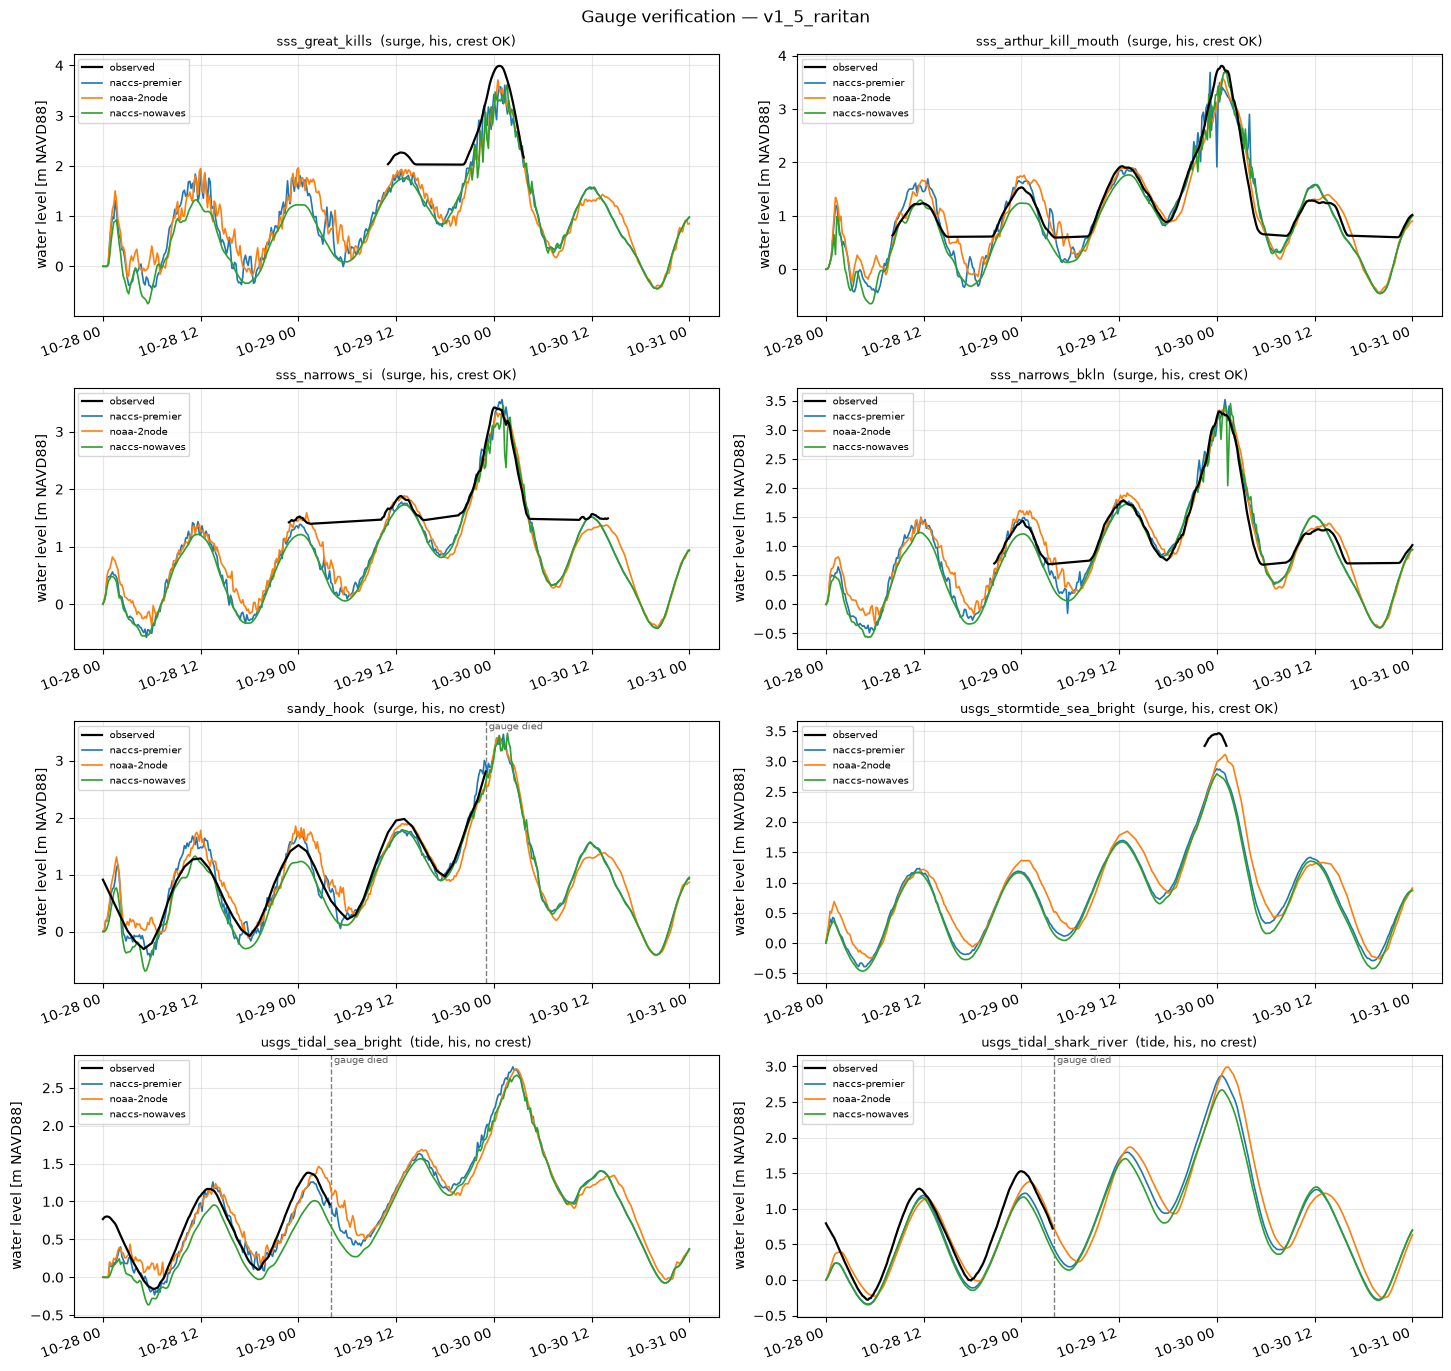

In [4]:
plots.plot_gauge_verification(RUNS);

## Gauge metrics — `tide` gauges: read range/phase. `surge` gauges: read peak.


In [5]:
m = pd.read_csv(EXP / "metrics.csv", index_col=0)

COLS = {
    "peak_obs": "peak_obs_{n}_m",
    "peak_mod": "peak_mod_full_{n}_m",
    "peak_err": "peak_err_{n}_m",
    "peak_lag_min": "peak_lag_{n}_min",
    "tide_obs_rng": "tide_obs_range_{n}_m",
    "tide_mod_rng": "tide_mod_range_{n}_m",
    "tide_damping": "tide_range_damping_{n}_m",
    "phase_lag_min": "phase_lag_{n}_min",
}

rows = []
for arm in m.index:
    for g in DOM.obs_gauges:
        r = {"arm": arm, "gauge": g.name, "kind": g.kind,
             "crest": "survives" if g.survives_crest else "DIED"}
        for label, pat in COLS.items():
            k = pat.format(n=g.name)
            r[label] = m.loc[arm, k] if k in m.columns else float("nan")
        # Sandy Hook died mid-storm: its only admissible peak is the pre-failure one.
        k = f"peak_err_prefail_{g.name}_m"
        if k in m.columns:
            r["peak_err"] = m.loc[arm, k]
            r["crest"] = "DIED (prefail)"
        rows.append(r)

gm = pd.DataFrame(rows).set_index(["gauge", "kind", "crest", "arm"]).round(3)
display(gm)


,,,,peak_obs,peak_mod,peak_err,peak_lag_min,tide_obs_rng,tide_mod_rng,tide_damping,phase_lag_min
gauge,kind,crest,arm,,,,,,,,
sss_great_kills,surge,survives,naccs-premier,3.991,3.605,-0.385,38.0,0.204,2.368,-2.164,NaN
sss_arthur_kill_mouth,surge,survives,naccs-premier,3.813,3.686,-0.128,-86.0,1.309,2.134,-0.824,9.1
sss_narrows_si,surge,survives,naccs-premier,3.424,3.557,0.133,54.0,0.407,1.820,-1.413,-46.5
sss_narrows_bkln,surge,survives,naccs-premier,3.316,3.520,0.205,36.0,1.035,2.015,-0.981,-120.0
sandy_hook,surge,DIED (prefail),naccs-premier,2.808,3.461,0.192,NaN,2.029,1.935,0.094,1.5
usgs_stormtide_sea_bright,surge,survives,naccs-premier,3.465,2.876,-0.589,-12.0,NaN,1.538,NaN,NaN
usgs_tidal_sea_bright,tide,DIED (prefail),naccs-premier,1.384,2.777,-0.125,NaN,1.283,1.180,0.103,22.0
usgs_tidal_shark_river,tide,DIED (prefail),naccs-premier,1.527,2.868,-0.311,NaN,1.539,1.429,0.110,12.6
sss_great_kills,surge,survives,naccs-nowaves,3.991,3.616,-0.374,58.0,0.204,1.695,-1.490,NaN


## HWM


/cache/home/tpj8/nj_sandy_sfincs/micromamba/envs/sfincs/lib/python3.14/site-packages/rioxarray/rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(


/cache/home/tpj8/nj_sandy_sfincs/micromamba/envs/sfincs/lib/python3.14/site-packages/rioxarray/rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(


[hwm] region clip: 38 of 107 marks are outside the domain region and are NOT scored (they would otherwise score as dry against bare earth)
[hwm] region clip: 38 of 107 marks are outside the domain region and are NOT scored (they would otherwise score as dry against bare earth)


/cache/home/tpj8/nj_sandy_sfincs/micromamba/envs/sfincs/lib/python3.14/site-packages/rioxarray/rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(


[hwm] region clip: 38 of 107 marks are outside the domain region and are NOT scored (they would otherwise score as dry against bare earth)


/cache/home/tpj8/nj_sandy_sfincs/micromamba/envs/sfincs/lib/python3.14/site-packages/rioxarray/rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(


[hwm] region clip: 38 of 107 marks are outside the domain region and are NOT scored (they would otherwise score as dry against bare earth)


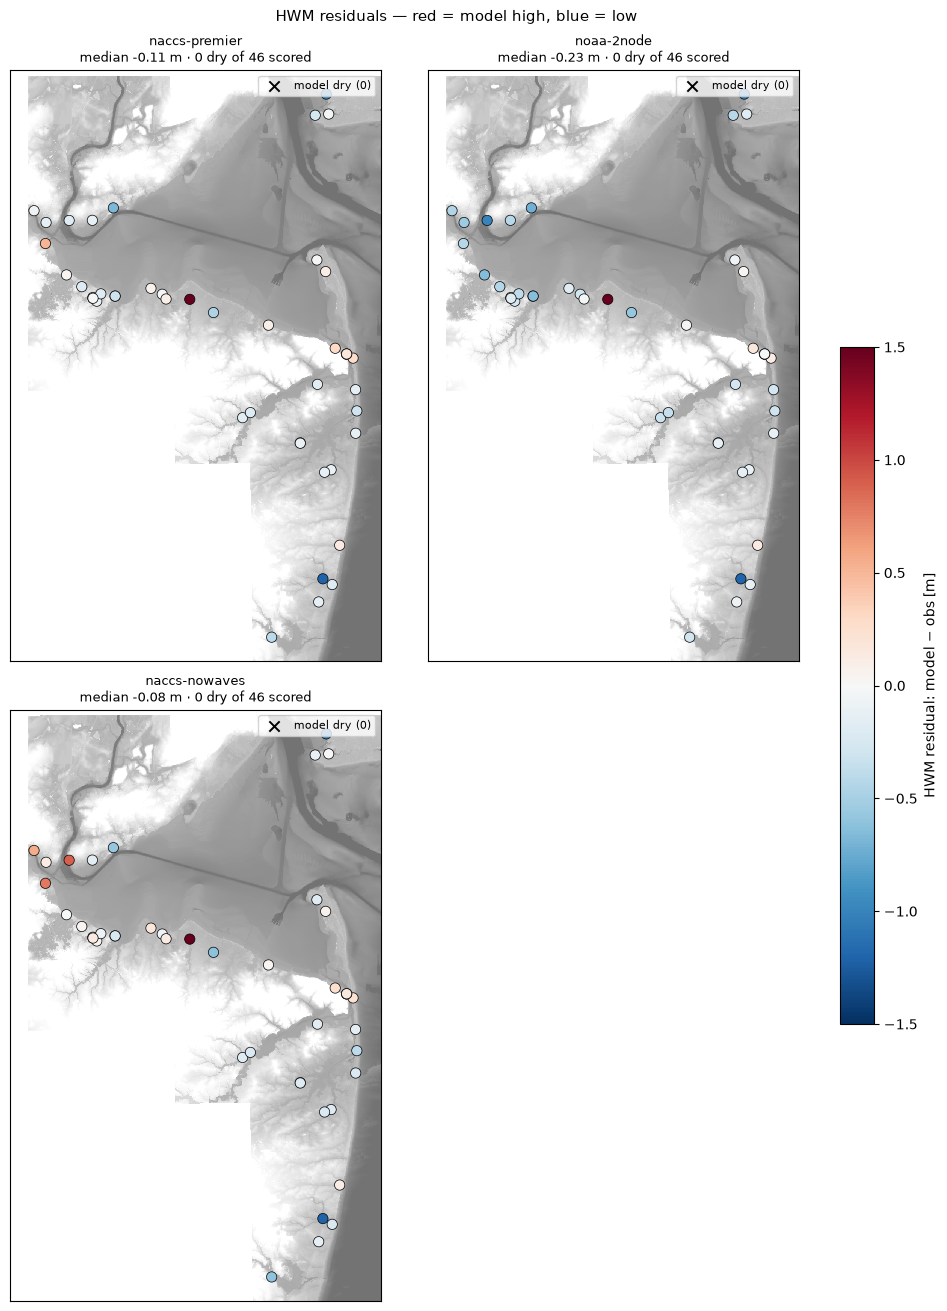

In [6]:
plots.plot_hwm_residual_panels(RUNS);

## MOTF — waves-on arms only


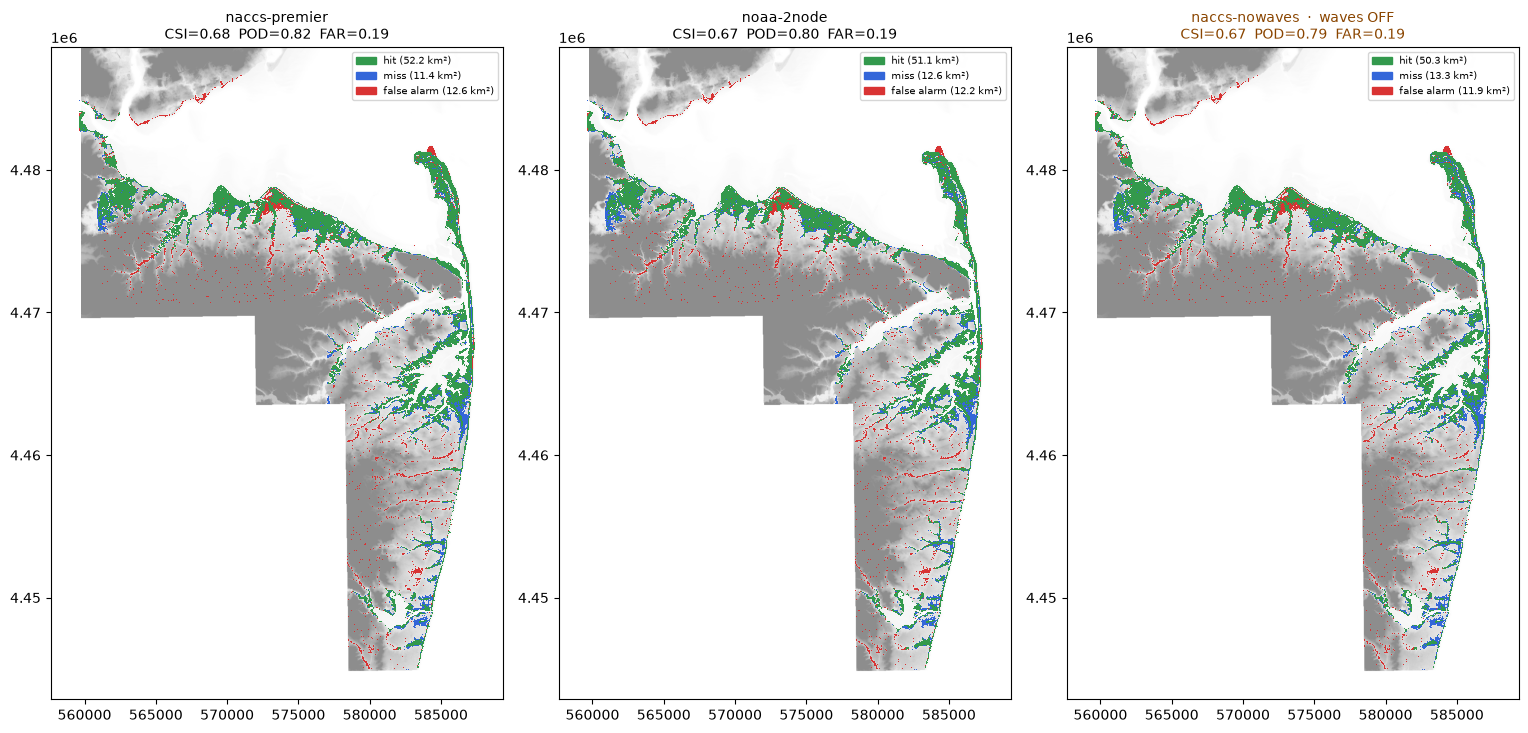

In [7]:
plots.plot_motf_panels(RUNS, ncol=3);

## Animations


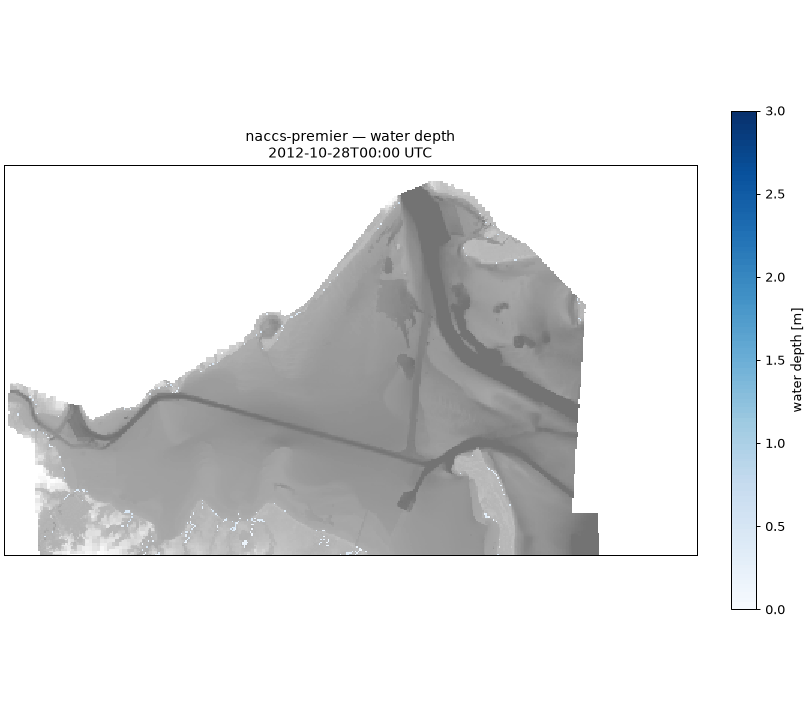

In [8]:
anim = animate.animate_field("naccs-premier", "depth", window="raritan", fps=6)
HTML(anim.to_jshtml())

In [9]:
anim = animate.animate_field("naccs-premier", "hm0", window="narrows", fps=6)
HTML(anim.to_jshtml())

## Interactive — pick a run, field, window


In [10]:
import holoviews as hv
import ipywidgets as widgets

hv.extension("bokeh")


@widgets.interact(
    run=list(RUNS.values()),
    var=["depth", "zs", "hm0", "tp"],
    window=sorted(DOM.map_windows),
)
def browse(run="naccs-premier", var="depth", window="raritan"):
    display(animate.explore_field(run, var=var, window=window))


## Save a GIF


In [11]:
out = ROOT / "reports" / "figures" / "v1_5_depth_raritan.gif"
out.parent.mkdir(parents=True, exist_ok=True)
anim = animate.animate_field("naccs-premier", "depth", window="raritan")
anim.save(out, writer="pillow", fps=6, dpi=90)
print(out, f"{out.stat().st_size / 1e6:.1f} MB")

/cache/home/tpj8/nj_bight_sfincs/reports/figures/v1_5_depth_raritan.gif 0.9 MB
